# 🏙️ Airbnb NYC Price Prediction

**Goal:** predict whether a New York City Airbnb listing is **high-priced** (top 25%) or **low-priced**,
and find out which features drive the price.

- **Dataset:** `Airbnb/new_york_listings_2024.csv` (20,758 NYC listings, 2024)
- **Models:** Logistic Regression (scikit-learn) vs. a Neural Network (TensorFlow/Keras)

Run the cells from top to bottom. Each step builds on the previous one.

## Step 0: Setup
Import the libraries, fix the random seed so results are the same every run,
and set up the file paths.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow's startup messages
import sys
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import tensorflow as tf
from tensorflow import keras

tf.get_logger().setLevel("ERROR")   # hide TensorFlow warnings (e.g. "no GPU found")

# Same random numbers every run -> same results every run
keras.utils.set_random_seed(42)

# Folder of this project, so file paths work no matter where you run from
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))   # running as a .py script
except NameError:
    BASE_DIR = os.getcwd()                                  # running in a notebook
DATA_FILE = os.path.join(BASE_DIR, "Airbnb", "new_york_listings_2024.csv")
CHART_DIR = os.path.join(BASE_DIR, "screenshots")
os.makedirs(CHART_DIR, exist_ok=True)

IN_NOTEBOOK = "ipykernel" in sys.modules


def save_chart(filename):
    """Save the current chart into the screenshots folder.
    In a notebook the chart is also shown below the cell."""
    plt.tight_layout()
    plt.savefig(os.path.join(CHART_DIR, filename), dpi=120)
    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()
        print("Saved chart:", filename)

## Step 1: Load the data

In [2]:
df = pd.read_csv(DATA_FILE)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (20758, 22)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1


## Step 2: Clean the data
Some number columns are stored as **text** because of special words:

| Column | Problem value | Fix |
|---|---|---|
| `rating` | `"No rating"` | convert to a number + add a `has_rating` 0/1 flag |
| `bedrooms` | `"Studio"` | a studio has 0 separate bedrooms |
| `baths` | `"Not specified"` | convert to a number |
| `license` | thousands of different license numbers | simple `has_license` 0/1 flag |
| `last_review` | a date | number of days since the last review |

Empty values are filled with the **median** (middle value), which extreme values don't pull around the way they pull the average.
Unrealistic prices ($0, or the top 1%, such as $100,000/night) are removed.

In [3]:
df_clean = df.copy()

# rating: "No rating" becomes empty (NaN); also keep a 0/1 flag for "has a rating"
df_clean["rating"] = pd.to_numeric(df_clean["rating"].str.strip(), errors="coerce")
df_clean["has_rating"] = df_clean["rating"].notna().astype(int)

# bedrooms: a "Studio" has 0 separate bedrooms
df_clean["bedrooms"] = pd.to_numeric(df_clean["bedrooms"].replace("Studio", "0"), errors="coerce")

# baths: "Not specified" becomes empty (NaN)
df_clean["baths"] = pd.to_numeric(df_clean["baths"], errors="coerce")

# license: "No License" / "Exempt" -> 0, a real license number -> 1
df_clean["has_license"] = (~df_clean["license"].isin(["No License", "Exempt"])).astype(int)

# last_review: how many days before the newest review in the data
# (a listing reviewed recently is probably more active)
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"], errors="coerce")
newest_date = df_clean["last_review"].max()
df_clean["days_since_last_review"] = (newest_date - df_clean["last_review"]).dt.days

# Fill empty values with the median
for col in ["rating", "bedrooms", "baths", "days_since_last_review"]:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Remove unrealistic prices
price_cap = df_clean["price"].quantile(0.99)
df_clean = df_clean[(df_clean["price"] > 0) & (df_clean["price"] <= price_cap)]

print(f"Kept {len(df_clean)} listings priced between $1 and ${price_cap:.0f} per night")
print("Missing values left:", df_clean[["rating", "bedrooms", "baths"]].isna().sum().sum())

Kept 20560 listings priced between $1 and $999 per night
Missing values left: 0


## Step 3: Create the label (high price vs. low price)
The dataset only has the raw price, so I create the label myself:
a listing is **high (1)** if its price is in the top 25% (75th percentile or above), otherwise **low (0)**.

In [4]:
high_price_cutoff = df_clean["price"].quantile(0.75)
df_clean["high_price"] = (df_clean["price"] >= high_price_cutoff).astype(int)

print(f"High-price cutoff: ${high_price_cutoff:.0f} per night")
print(df_clean["high_price"].value_counts())

High-price cutoff: $198 per night
high_price
0    15400
1     5160
Name: count, dtype: int64


## Step 4: Explore the data (EDA)
### 4a: Class distribution
How many listings are in each group? This checks for **class imbalance**.

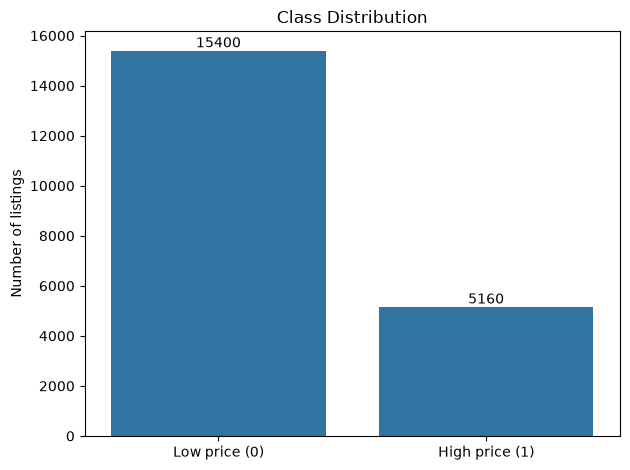

In [5]:
ax = sns.countplot(x="high_price", data=df_clean)
ax.bar_label(ax.containers[0])
plt.xticks([0, 1], ["Low price (0)", "High price (1)"])
plt.xlabel("")
plt.ylabel("Number of listings")
plt.title("Class Distribution")
save_chart("class_distribution.png")

### 4b: Bedrooms by price category
Do high-price listings have more bedrooms?

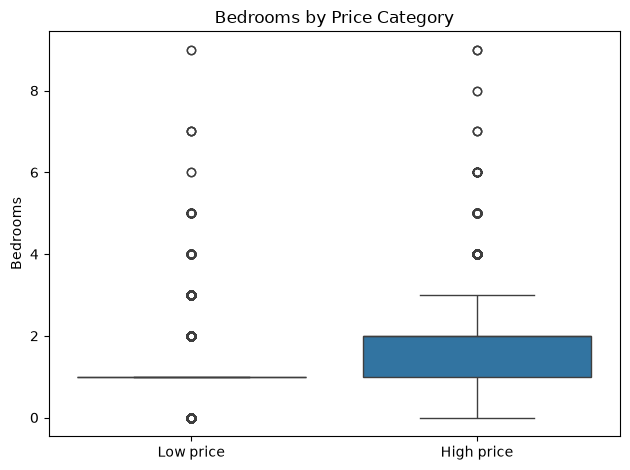

In [6]:
sns.boxplot(x="high_price", y="bedrooms", data=df_clean)
plt.xticks([0, 1], ["Low price", "High price"])
plt.xlabel("")
plt.ylabel("Bedrooms")
plt.title("Bedrooms by Price Category")
save_chart("bedrooms_boxplot.png")

### 4c: High-price share by borough and room type
What percent of listings are high-price in each borough and in each room type?

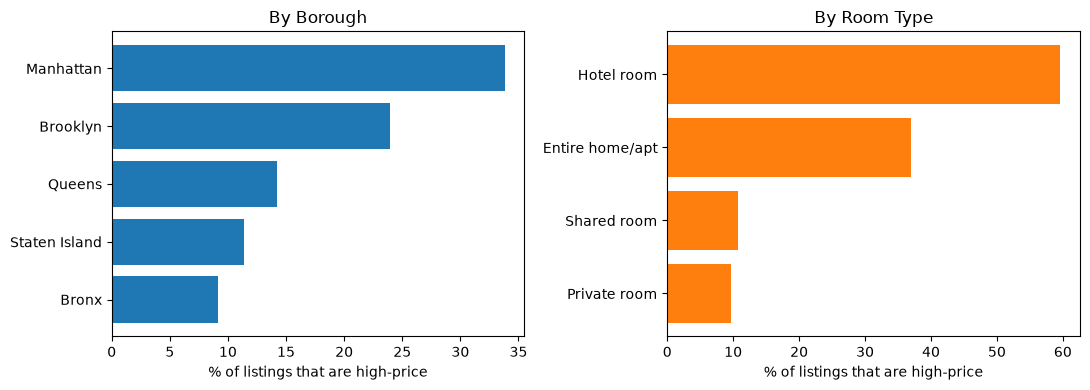

neighbourhood_group
Bronx             9.2
Staten Island    11.4
Queens           14.3
Brooklyn         23.9
Manhattan        33.8
Name: high_price, dtype: float64
room_type
Private room        9.7
Shared room        10.8
Entire home/apt    37.0
Hotel room         59.6
Name: high_price, dtype: float64


In [7]:
borough_share = df_clean.groupby("neighbourhood_group")["high_price"].mean().sort_values()
room_share = df_clean.groupby("room_type")["high_price"].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(borough_share.index, borough_share.values * 100)
axes[0].set_xlabel("% of listings that are high-price")
axes[0].set_title("By Borough")
axes[1].barh(room_share.index, room_share.values * 100, color="tab:orange")
axes[1].set_xlabel("% of listings that are high-price")
axes[1].set_title("By Room Type")
save_chart("high_price_share.png")

print((borough_share * 100).round(1))
print((room_share * 100).round(1))

## Step 5: Prepare the data for the models
- **Drop** IDs and free text (`id`, `name`, `host_id`, `host_name`), which don't generalize.
- **Drop** `neighbourhood` (200+ small areas). The borough and latitude/longitude already describe location.
- **Drop** `license` and `last_review`, which were already turned into new columns in Step 2.
- **Drop `price`.** The label was made *from* price, so keeping it would let the model cheat (**data leakage**).
- **One-hot encode** `room_type` and borough into 0/1 columns.
- **Split** 80% train / 20% test. `stratify` keeps the same high/low ratio in both parts.
- **Scale** the features so big-number columns don't outweigh small ones. The scaler learns from training data only.

In [8]:
drop_cols = ["id", "name", "host_id", "host_name", "neighbourhood",
             "license", "last_review", "price"]
df_model = df_clean.drop(columns=drop_cols)

df_model = pd.get_dummies(df_model, columns=["room_type", "neighbourhood_group"], dtype=int)

# X = the inputs (features), y = the answer to predict (label)
X = df_model.drop(columns=["high_price"])
y = df_model["high_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn the scale from training data
X_test_scaled = scaler.transform(X_test)         # apply the same scale to test data

print("Number of features:", X.shape[1])
print("Training rows:", len(X_train), "| Test rows:", len(X_test))
print("Features:", list(X.columns))

Number of features: 24
Training rows: 16448 | Test rows: 4112
Features: ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'rating', 'bedrooms', 'beds', 'baths', 'has_rating', 'has_license', 'days_since_last_review', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']


## Step 6: Baseline — always guess "low"
Because about 75% of listings are low-price, a "model" that always answers *low* is already ~75% accurate,
but it never finds a single high-price listing (F1 = 0). Any real model must beat this.

In [9]:
baseline_pred = np.zeros(len(y_test), dtype=int)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print(f"Baseline Accuracy: {baseline_accuracy:.3f}")
print(f"Baseline F1 Score: {baseline_f1:.3f}")

Baseline Accuracy: 0.749
Baseline F1 Score: 0.000


## Step 7: Model 1 — Logistic Regression
### 7a: Default model

In [10]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_default = log_model.predict(X_test_scaled)

lr_default_accuracy = accuracy_score(y_test, y_pred_default)
lr_default_f1 = f1_score(y_test, y_pred_default)
print(f"Default Accuracy: {lr_default_accuracy:.3f}")
print(f"Default F1 Score: {lr_default_f1:.3f}")

Default Accuracy: 0.807
Default F1 Score: 0.512


### 7b: Tune it with GridSearchCV
GridSearchCV tries every combination of settings with 5-fold cross-validation and keeps the one with the best F1 score.
- `C` sets how strict the model is. A small C gives a simpler model.
- `class_weight="balanced"` makes mistakes on the smaller high-price group count more.

In [11]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="f1")
grid.fit(X_train_scaled, y_train)
print("Best settings:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_lr = best_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
print(f"Tuned Accuracy: {lr_accuracy:.3f}")
print(f"Tuned F1 Score: {lr_f1:.3f}")

Best settings: {'C': 10, 'class_weight': 'balanced'}
Tuned Accuracy: 0.747
Tuned F1 Score: 0.594


### 7c: What drives a high price?
Each feature gets a **coefficient**. A positive one pushes a listing toward *high price*, and a negative one pushes it toward *low price*.
Because the features were scaled, the coefficient sizes can be compared with each other.

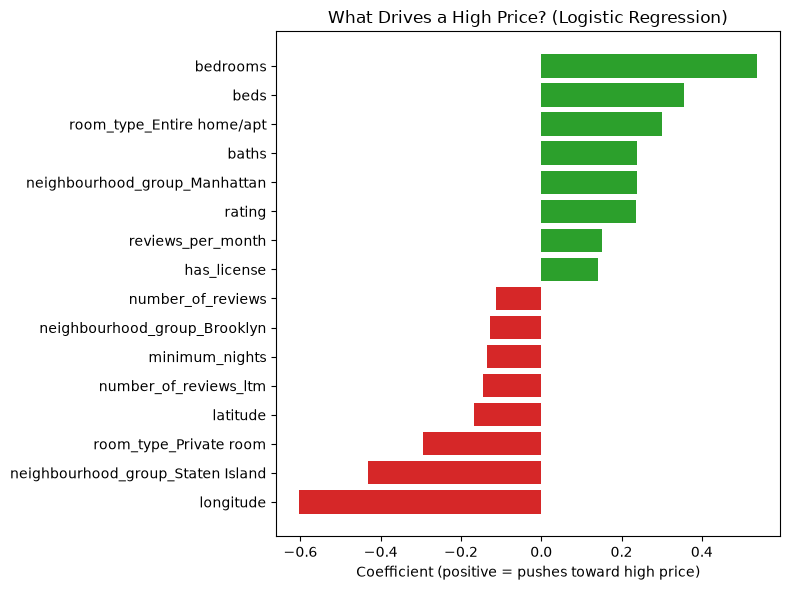

In [12]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": best_model.coef_[0],
}).sort_values("coefficient", ascending=False)

top_features = pd.concat([coefficients.head(8), coefficients.tail(8)])
colors = ["tab:green" if c > 0 else "tab:red" for c in top_features["coefficient"]]

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["coefficient"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Coefficient (positive = pushes toward high price)")
plt.title("What Drives a High Price? (Logistic Regression)")
save_chart("coefficients.png")

## Step 8: Model 2 — Neural Network (Keras)
### 8a: Build and train
- 2 hidden layers (64 and 32 units, ReLU), plus a sigmoid output that gives the probability of *high price*.
- **Dropout** randomly switches off 20% of units during training to reduce overfitting.
- **Adam** adjusts the learning speed automatically. **Binary cross-entropy** is the standard loss for yes/no problems.
- **Early stopping** stops training once validation loss hasn't improved for 10 epochs, then goes back to the best version.

This cell takes about 30–60 seconds.

In [13]:
nn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
])
nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="binary_crossentropy",
                 metrics=["accuracy"])
nn_model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                           restore_best_weights=True)

t0 = time.time()
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,                 # upper limit; early stopping usually ends sooner
    batch_size=32,
    validation_split=0.2,       # hold out 20% of training data to check progress
    callbacks=[early_stop],
    verbose=0,
)
print(f"Trained for {len(history.history['loss'])} epochs in {time.time() - t0:.1f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

Trained for 53 epochs in 121.9s


### 8b: Training curves
If the validation lines flatten while the training lines keep improving, the model has started to **overfit**.
That's the point where early stopping ends training.

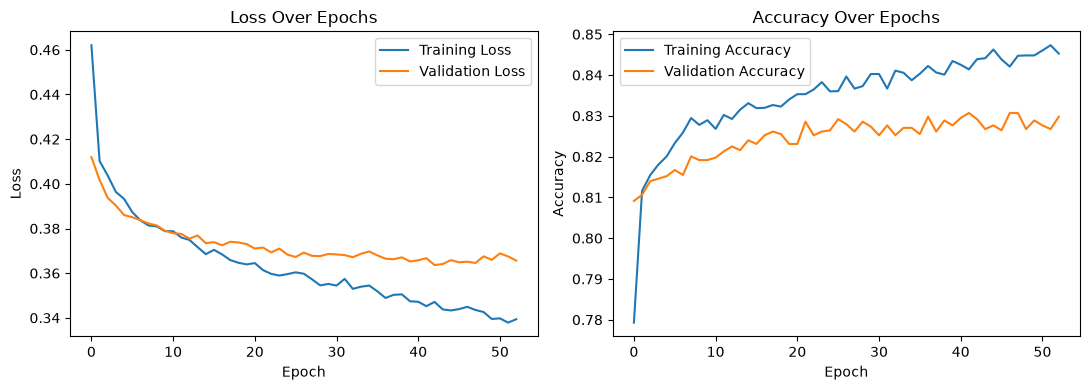

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Over Epochs")
axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Training Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Over Epochs")
axes[1].legend()
save_chart("training_curves.png")

### 8c: Test the neural network
A probability of 0.5 or higher counts as *high price*.

In [15]:
y_pred_probs = nn_model.predict(X_test_scaled, verbose=0)
y_pred_nn = (y_pred_probs >= 0.5).astype(int).ravel()

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn)
print(f"Neural Network Accuracy: {nn_accuracy:.3f}")
print(f"Neural Network F1 Score: {nn_f1:.3f}")

Neural Network Accuracy: 0.838
Neural Network F1 Score: 0.632


## Step 9: Compare the models
**Accuracy** is how often the model is right overall. **F1** is how well it finds the smaller high-price group, and it's the more important number here.

                        Model  Accuracy  F1 Score
        Baseline (always low)     0.749     0.000
Logistic Regression (default)     0.807     0.512
  Logistic Regression (tuned)     0.747     0.594
               Neural Network     0.838     0.632


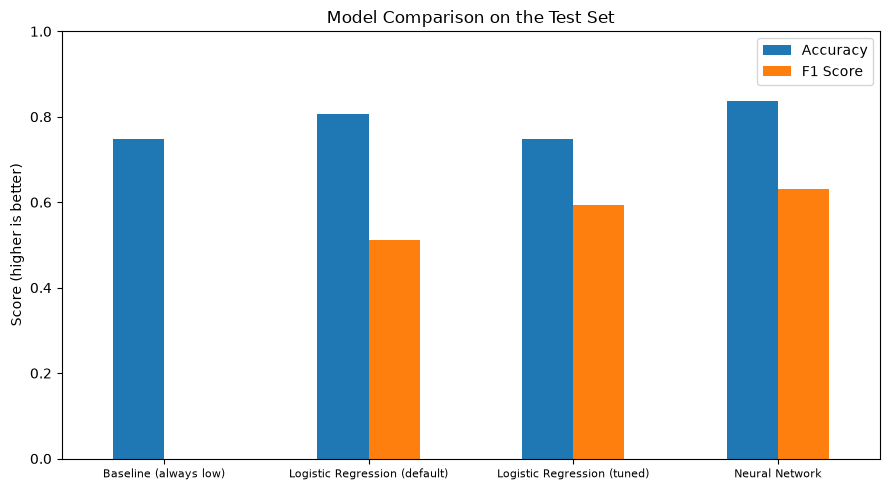

In [16]:
results = pd.DataFrame({
    "Model": ["Baseline (always low)", "Logistic Regression (default)",
              "Logistic Regression (tuned)", "Neural Network"],
    "Accuracy": [baseline_accuracy, lr_default_accuracy, lr_accuracy, nn_accuracy],
    "F1 Score": [baseline_f1, lr_default_f1, lr_f1, nn_f1],
}).round(3)
print(results.to_string(index=False))

results.set_index("Model").plot.bar(figsize=(9, 5), rot=0)
plt.ylim(0, 1)
plt.ylabel("Score (higher is better)")
plt.xlabel("")
plt.title("Model Comparison on the Test Set")
plt.xticks(fontsize=8)
save_chart("results_comparison.png")